# Feature Analysis & Visualization

**Project:** Fraudulent Donation Link Detection Using AI  
**Purpose:** for every feature built so far, visualize *how well it separates legitimate links from scam (phishing) links*, and export CSV files that split the data by each feature.

**Label convention:** `0 = Legitimate`, `1 = Scam / Fraudulent`.

Features analysed:
1. `url_length` — total characters in the URL
2. `has_https` — whether the URL uses HTTPS
3. `num_subdomains` — number of sub-domains
4. `tld_length` — length of the TLD (e.g. `.com` = 3, `.uk` = 2, `.host` = 4)  ← **new**
5. `two_letter_tld` — whether the URL ends in a 2-letter (country-code) TLD

Each feature gets a **clear plot**, a **scam-rate summary CSV**, and **split CSVs**. A final section ranks all features by separating power.

In [1]:
# ---- Setup ----
import pandas as pd
import re, os
from urllib.parse import urlparse
import matplotlib.pyplot as plt
%matplotlib inline

# consistent, clean plot styling
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": "#888", "axes.linewidth": 0.8,
})

DATA_PATH = "../data/dataset_live_links_v2.csv"   # EDIT if your file is elsewhere

df = pd.read_csv(DATA_PATH)
df = df[["url", "label"]].copy()
print("Loaded:", df.shape)
print(df["label"].value_counts().rename({0: "Legit", 1: "Scam"}))
df.head()

Loaded: (804, 2)
label
Scam     441
Legit    363
Name: count, dtype: int64


,url,label
0,https://www.icecream.com,0
1,https://proud-lake-5717.kx7hcssq.workers.dev/,1
2,https://www.stmusic.at,0
3,http://icuwtzw.cloudaccess.host/,1
4,http://bcc56.freehostpro.com/,1


## 1. Rebuild the features

Self-contained: features are rebuilt from the `url` column so the notebook runs top-to-bottom on its own.

In [2]:
# ---- Feature functions ----
def get_url_length(url):
    return len(url)

def get_has_https(url):
    return 1 if urlparse(url).scheme == "https" else 0

def get_num_subdomains(url):
    host = urlparse(url).netloc
    return 0 if host == "" else max(host.count(".") - 1, 0)

def get_tld_length(url):
    # length of the last part of the host (the TLD): .com -> 3, .uk -> 2, .host -> 4
    host = urlparse(url).netloc
    return len(host.split(".")[-1]) if "." in host else 0

def get_two_letter_tld(url):
    # 1 if the URL contains a 2-letter country-code-style TLD (.us, .uk, .at ...)
    return 1 if re.findall(r"\.[a-zA-Z]{2}\b", url) else 0

def get_special_char_count(url):
    # count every character that is NOT a letter or digit
    return len(re.findall(r"[^a-zA-Z0-9]", url))

def get_suspicious_keyword_count(url):
    # count scam-related words in the URL
    pattern = r"donate|urgent|help|verify|secure|account|login|gift|fund|claim"
    return len(re.findall(pattern, url.lower()))

df["url_length"]               = df["url"].apply(get_url_length)
df["has_https"]                = df["url"].apply(get_has_https)
df["num_subdomains"]           = df["url"].apply(get_num_subdomains)
df["tld_length"]               = df["url"].apply(get_tld_length)
df["two_letter_tld"]           = df["url"].apply(get_two_letter_tld)
df["special_character_count"]  = df["url"].apply(get_special_char_count)
df["suspicious_keyword_count"] = df["url"].apply(get_suspicious_keyword_count)

df.head()


,url,label,url_length,has_https,num_subdomains,tld_length,two_letter_tld,special_character_count,suspicious_keyword_count
0,https://www.icecream.com,0,24,1,1,3,0,5,0
1,https://proud-lake-5717.kx7hcssq.workers.dev/,1,45,1,2,3,0,9,0
2,https://www.stmusic.at,0,22,1,1,2,1,5,0
3,http://icuwtzw.cloudaccess.host/,1,32,0,1,4,0,6,0
4,http://bcc56.freehostpro.com/,1,29,0,1,3,0,6,0


In [3]:
# ---- Output folder + styled helper functions ----
OUT = "../outputs/feature_analysis"
os.makedirs(OUT, exist_ok=True)

LEGIT_C, SCAM_C, ACCENT = "#3B82C4", "#E05252", "#8E5FD0"

def _style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

def value_summary(df, feature):
    g = df.groupby(feature)["label"].agg(count="count", scam="sum")
    g["legit"] = g["count"] - g["scam"]
    g["scam_rate"] = (g["scam"] / g["count"]).round(3)
    return g[["count", "legit", "scam", "scam_rate"]]

def bin_summary(df, feature, bins=6):
    tmp = df.copy()
    tmp["bin"] = pd.cut(tmp[feature], bins=bins)
    g = tmp.groupby("bin", observed=True)["label"].agg(count="count", scam="sum")
    g["legit"] = g["count"] - g["scam"]
    g["scam_rate"] = (g["scam"] / g["count"]).round(3)
    return g[["count", "legit", "scam", "scam_rate"]]

def plot_numeric(df, feature):
    """For a continuous feature: an easy-to-read average comparison + a clean box plot."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    # LEFT: average value per class (easy to read)
    stats = df.groupby("label")[feature].agg(["mean", "median"])
    x, w = [0, 1], 0.35
    ax[0].bar([i - w/2 for i in x], stats["mean"],   w, label="mean",   color=LEGIT_C, edgecolor="white")
    ax[0].bar([i + w/2 for i in x], stats["median"], w, label="median", color=SCAM_C,  edgecolor="white")
    ax[0].set_xticks(x); ax[0].set_xticklabels(["Legit", "Scam"])
    ax[0].set_title(f"Average {feature} by class"); ax[0].set_ylabel(feature); ax[0].legend(frameon=False)
    for i in x:
        ax[0].text(i - w/2, stats["mean"].iloc[i],   f"{stats['mean'].iloc[i]:.0f}",   ha="center", va="bottom", fontsize=9)
        ax[0].text(i + w/2, stats["median"].iloc[i], f"{stats['median'].iloc[i]:.0f}", ha="center", va="bottom", fontsize=9)
    _style(ax[0])
    # RIGHT: box plot with outliers hidden so the boxes are actually visible
    ax[1].boxplot([df[df.label == 0][feature], df[df.label == 1][feature]],
                  labels=["Legit", "Scam"], showfliers=False, patch_artist=True,
                  boxprops=dict(facecolor="#EAF1FA", edgecolor=LEGIT_C),
                  medianprops=dict(color=SCAM_C, linewidth=2))
    ax[1].set_title(f"{feature} spread (outliers hidden)"); ax[1].set_ylabel(feature)
    _style(ax[1])
    fig.suptitle(feature, fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{OUT}/{feature}_plot.png", dpi=130, bbox_inches="tight")
    plt.show()

def plot_discrete(df, feature):
    """For a binary/discrete feature: counts by class + scam rate per value."""
    ct = pd.crosstab(df[feature], df["label"])
    rate = df.groupby(feature)["label"].mean()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    ct.plot(kind="bar", ax=ax[0], color=[LEGIT_C, SCAM_C], width=0.8, edgecolor="white")
    ax[0].set_title("Counts by class"); ax[0].set_xlabel(feature); ax[0].set_ylabel("count")
    ax[0].legend(["Legit (0)", "Scam (1)"], frameon=False); ax[0].tick_params(axis="x", rotation=0)
    _style(ax[0])
    ax[1].bar(rate.index.astype(str), rate.values, color=ACCENT, width=0.7, edgecolor="white")
    ax[1].set_ylim(0, 1.15)     # headroom so labels don't collide with the title
    ax[1].set_title("Scam rate by value"); ax[1].set_xlabel(feature); ax[1].set_ylabel("scam rate")
    for i, v in enumerate(rate.values):
        if v > 0.9:  # place label INSIDE the bar when it's near the top
            ax[1].text(i, v - 0.08, f"{v:.0%}", ha="center", color="white", fontweight="bold")
        else:
            ax[1].text(i, v + 0.03, f"{v:.0%}", ha="center", fontweight="bold")
    _style(ax[1])
    fig.suptitle(feature, fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(f"{OUT}/{feature}_plot.png", dpi=130, bbox_inches="tight")
    plt.show()

print("Helpers ready. Outputs ->", OUT)

Helpers ready. Outputs -> ../outputs/feature_analysis


## 2. `url_length`   *(clearer plots)*

**Hypothesis:** scam links are often longer. The left chart compares the **average** length per class (easy to read); the right box plot shows the **spread** with extreme outliers hidden so the boxes are visible.

C:\Users\User\AppData\Local\Temp\ipykernel_1648\1465142534.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df[df.label == 0][feature], df[df.label == 1][feature]],


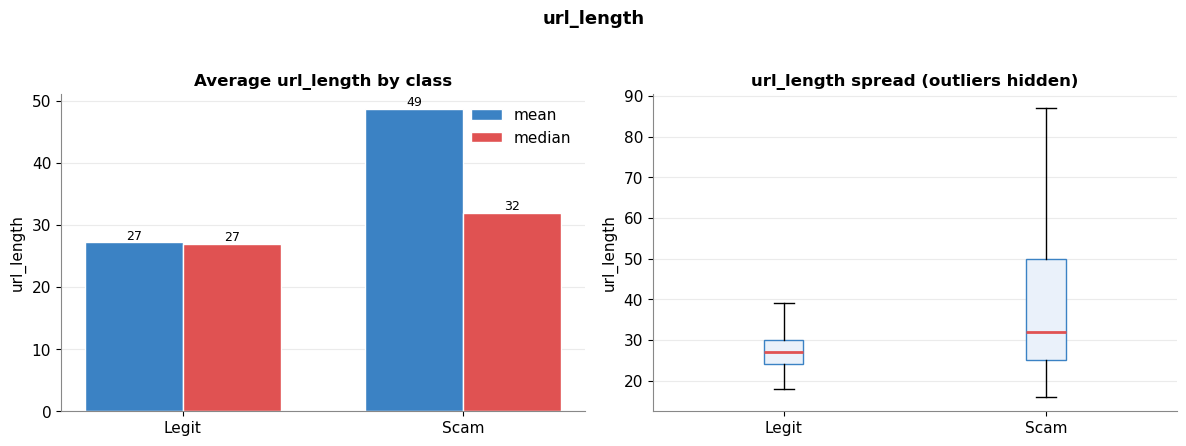

                  count  legit  scam  scam_rate
bin                                            
(13.963, 355.5]     802    363   439      0.547
(355.5, 695.0]        1      0     1      1.000
(1713.5, 2053.0]      1      0     1      1.000

Median = 28 | Mean length -> Legit: 27.2 | Scam: 48.7


In [4]:
plot_numeric(df, "url_length")

summary = bin_summary(df, "url_length", bins=6)
summary.to_csv(f"{OUT}/url_length_summary.csv")
print(summary)

med = df["url_length"].median()
df[df.url_length >  med][["url", "label"]].to_csv(f"{OUT}/url_length_long.csv",  index=False)
df[df.url_length <= med][["url", "label"]].to_csv(f"{OUT}/url_length_short.csv", index=False)
print(f"\nMedian = {med:.0f} | Mean length -> Legit:",
      round(df[df.label==0].url_length.mean(),1), "| Scam:", round(df[df.label==1].url_length.mean(),1))

## 3. `has_https`

**Hypothesis:** legitimate sites almost always use HTTPS; scam links more often skip it.

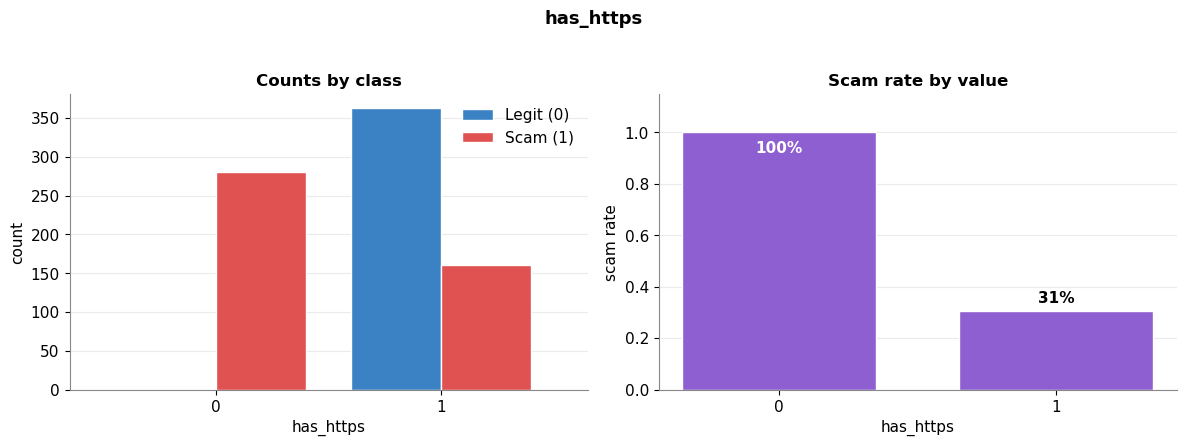

           count  legit  scam  scam_rate
has_https                               
0            280      0   280      1.000
1            524    363   161      0.307


In [5]:
plot_discrete(df, "has_https")

value_summary(df, "has_https").to_csv(f"{OUT}/has_https_summary.csv")
print(value_summary(df, "has_https"))

df[df.has_https == 1][["url", "label"]].to_csv(f"{OUT}/https_yes.csv", index=False)
df[df.has_https == 0][["url", "label"]].to_csv(f"{OUT}/https_no.csv",  index=False)

## 4. `num_subdomains`

**Hypothesis:** phishing links often stack more sub-domains.

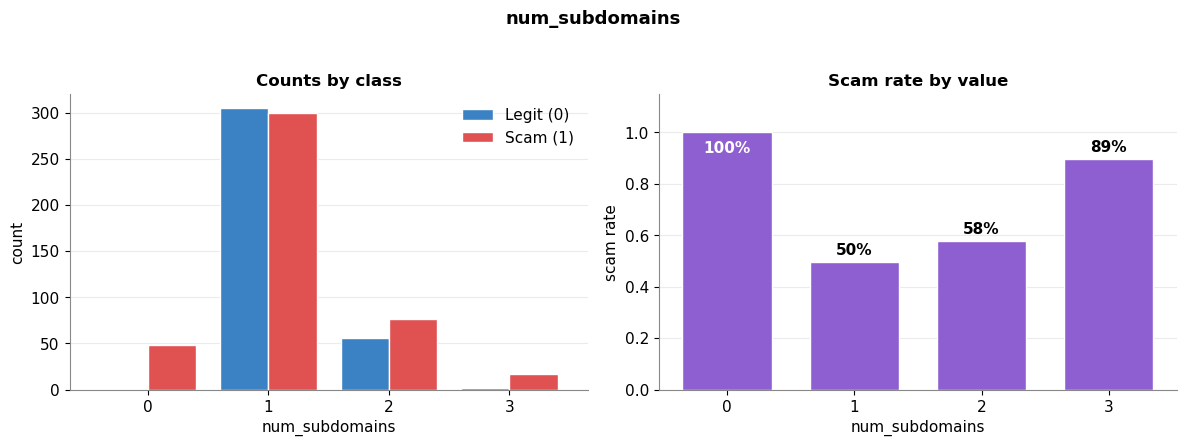

                count  legit  scam  scam_rate
num_subdomains                               
0                  48      0    48      1.000
1                 605    305   300      0.496
2                 132     56    76      0.576
3                  19      2    17      0.895


In [6]:
plot_discrete(df, "num_subdomains")

value_summary(df, "num_subdomains").to_csv(f"{OUT}/num_subdomains_summary.csv")
print(value_summary(df, "num_subdomains"))

df[df.num_subdomains >= 2][["url", "label"]].to_csv(f"{OUT}/subdomains_2plus.csv", index=False)
df[df.num_subdomains <  2][["url", "label"]].to_csv(f"{OUT}/subdomains_under2.csv", index=False)

## 5. `tld_length`   *(new feature)*

**What it is:** the length of the TLD — the last part of the host. `.com` = 3, `.uk` = 2, `.host` = 4, `.online` = 6.  
**Hypothesis:** scammers sometimes use unusual long TLDs (`.online`, `.click`, `.support`) or cheap country codes. We check whether TLD length differs between legit and scam.

*(Note: this is a richer version of `two_letter_tld` — instead of just "is it 2 letters?", it measures the actual length.)*

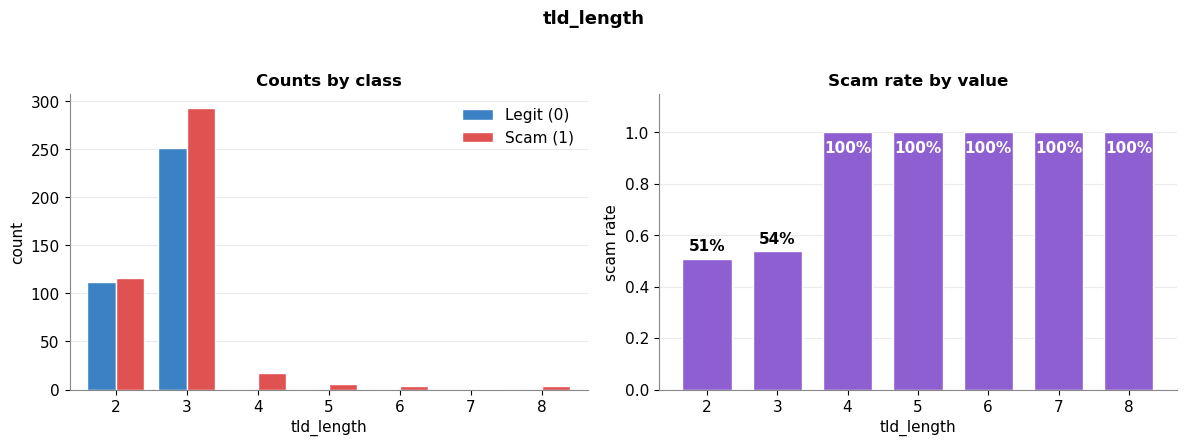

            count  legit  scam  scam_rate
tld_length                               
2             228    112   116      0.509
3             544    251   293      0.539
4              17      0    17      1.000
5               6      0     6      1.000
6               4      0     4      1.000
7               1      0     1      1.000
8               4      0     4      1.000


In [7]:
plot_discrete(df, "tld_length")   # discrete small values, so the bar view is clearest

value_summary(df, "tld_length").to_csv(f"{OUT}/tld_length_summary.csv")
print(value_summary(df, "tld_length"))

# split CSVs: standard TLD length (2-3, like .uk/.com) vs unusual (4+)
df[df.tld_length >= 4][["url", "label"]].to_csv(f"{OUT}/tld_length_long.csv",   index=False)
df[df.tld_length <  4][["url", "label"]].to_csv(f"{OUT}/tld_length_normal.csv", index=False)

## 6. `two_letter_tld`   *(Self Test)*

Turns your `\.[a-zA-Z]{2}\b` regex into a 0/1 feature and tests it across the **whole** dataset (your earlier `TwoLettersFiltered.csv` only looked inside the "yes" group).

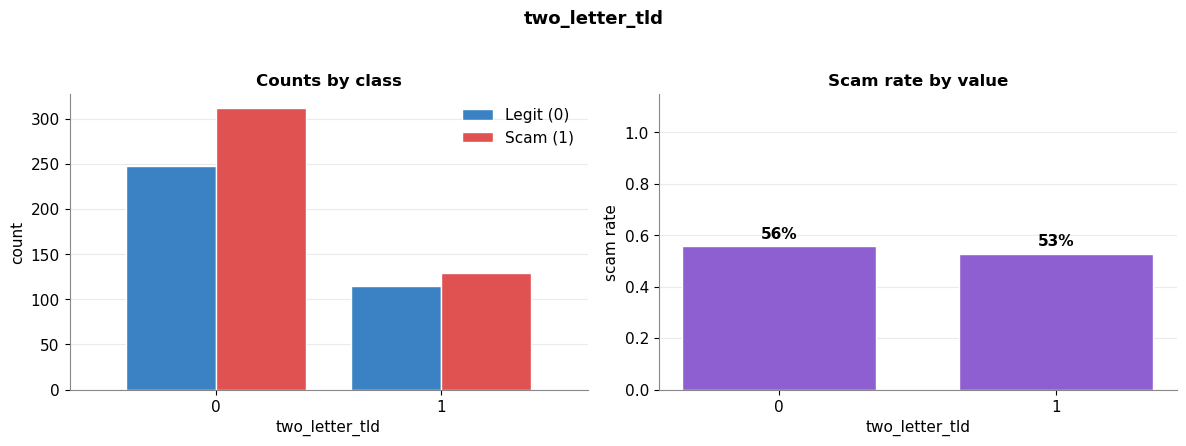

                count  legit  scam  scam_rate
two_letter_tld                               
0                 560    248   312      0.557
1                 244    115   129      0.529


In [8]:
plot_discrete(df, "two_letter_tld")

value_summary(df, "two_letter_tld").to_csv(f"{OUT}/two_letter_tld_summary.csv")
print(value_summary(df, "two_letter_tld"))

df[df.two_letter_tld == 1][["url", "label"]].to_csv(f"{OUT}/two_letter_tld_yes.csv", index=False)
df[df.two_letter_tld == 0][["url", "label"]].to_csv(f"{OUT}/two_letter_tld_no.csv",  index=False)

## 7. `special_character_count`  

**Hypothesis:** scam URLs are packed with special characters — dashes, digits, `%`, `@`, slashes. If so, the average count should be higher for scam links. Shown as an average comparison + a box plot with outliers hidden.

C:\Users\User\AppData\Local\Temp\ipykernel_1648\1465142534.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df[df.label == 0][feature], df[df.label == 1][feature]],


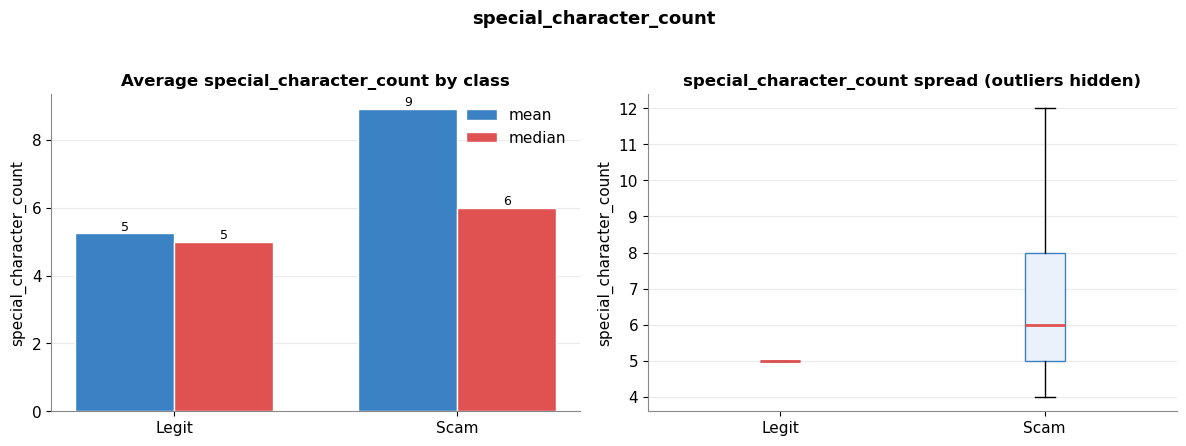

                  count  legit  scam  scam_rate
bin                                            
(3.329, 115.833]    803    363   440      0.548
(563.167, 675.0]      1      0     1      1.000

Median = 5 | Mean special chars -> Legit: 5.2 | Scam: 8.9


In [9]:
plot_numeric(df, "special_character_count")

bin_summary(df, "special_character_count", bins=6).to_csv(f"{OUT}/special_character_count_summary.csv")
print(bin_summary(df, "special_character_count", bins=6))

med = df["special_character_count"].median()
df[df.special_character_count >  med][["url", "label"]].to_csv(f"{OUT}/special_char_high.csv", index=False)
df[df.special_character_count <= med][["url", "label"]].to_csv(f"{OUT}/special_char_low.csv",  index=False)
print(f"\nMedian = {med:.0f} | Mean special chars -> Legit:",
      round(df[df.label==0].special_character_count.mean(),1),
      "| Scam:", round(df[df.label==1].special_character_count.mean(),1))

## 8. `suspicious_keyword_count` 

**Hypothesis:** scam URLs more often contain words like *donate, urgent, verify, login, gift*. Links with 1+ suspicious keyword should skew more towards scam.

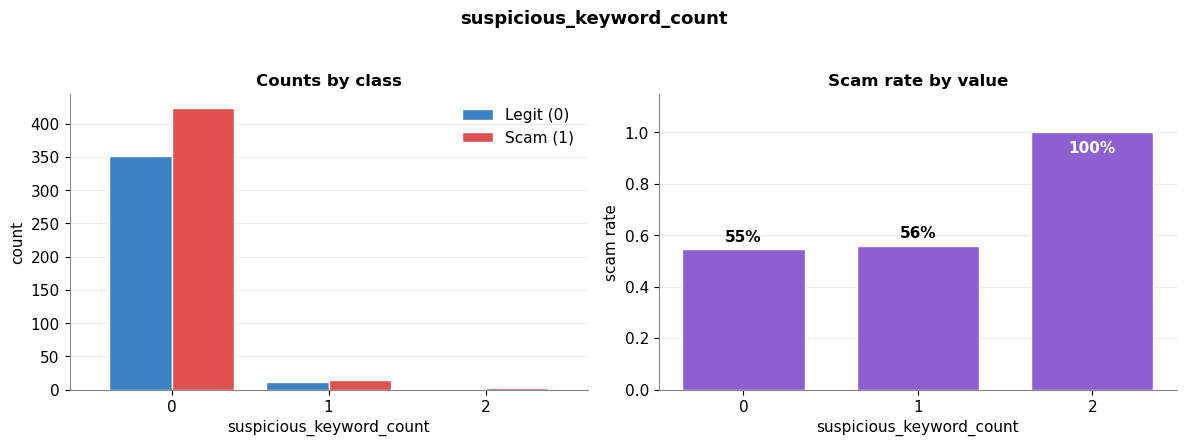

                          count  legit  scam  scam_rate
suspicious_keyword_count                               
0                           776    352   424      0.546
1                            25     11    14      0.560
2                             3      0     3      1.000


In [10]:
plot_discrete(df, "suspicious_keyword_count")

value_summary(df, "suspicious_keyword_count").to_csv(f"{OUT}/suspicious_keyword_count_summary.csv")
print(value_summary(df, "suspicious_keyword_count"))

df[df.suspicious_keyword_count >= 1][["url", "label"]].to_csv(f"{OUT}/has_suspicious_keyword.csv", index=False)
df[df.suspicious_keyword_count == 0][["url", "label"]].to_csv(f"{OUT}/no_suspicious_keyword.csv",  index=False)

## 9. Overall comparison — which features separate best?

Correlation of each feature with the label. Near 0 = weak separator; far from 0 = strong. Longest bar = strongest.

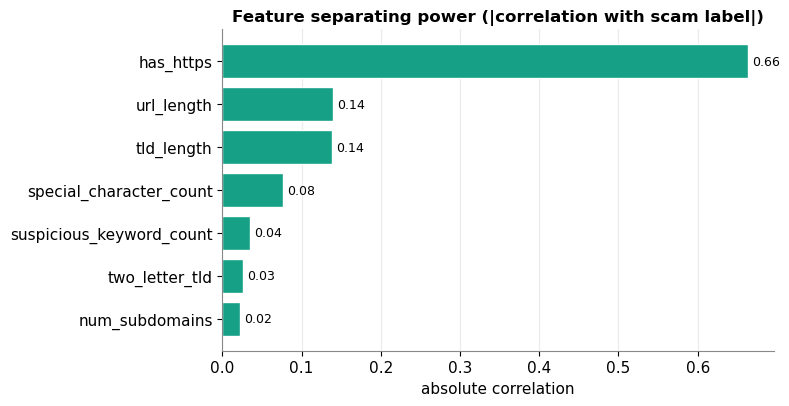

                 feature  correlation_with_scam  abs_strength
               has_https                 -0.663         0.663
              url_length                  0.140         0.140
              tld_length                  0.138         0.138
 special_character_count                  0.077         0.077
suspicious_keyword_count                  0.035         0.035
          two_letter_tld                 -0.026         0.026
          num_subdomains                 -0.023         0.023


In [11]:
feats = ["url_length", "has_https", "num_subdomains", "tld_length",
         "two_letter_tld", "special_character_count", "suspicious_keyword_count"]

corr = df[feats + ["label"]].corr()["label"].drop("label").fillna(0)
strength = corr.abs().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(strength.index, strength.values, color="#16A085", edgecolor="white")
ax.set_title("Feature separating power (|correlation with scam label|)")
ax.set_xlabel("absolute correlation")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)
for i, v in enumerate(strength.values):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}/feature_ranking.png", dpi=130, bbox_inches="tight")
plt.show()

ranking = pd.DataFrame({
    "feature": corr.index,
    "correlation_with_scam": corr.round(3).values,
    "abs_strength": corr.abs().round(3).values
}).sort_values("abs_strength", ascending=False)
ranking.to_csv(f"{OUT}/feature_ranking.csv", index=False)
print(ranking.to_string(index=False))